## To Do List
  1. Constructing the exact BW peaks
  2. Constructing the training data - correlators with noise
  3. Preparing the two NN representations
  4. Writing the Training loops
  5. Implementing the two losses with $\rho(\omega)$ the reconstructed spectral function and $\tilde{\rho}(\omega)$ - the ground truth
      - MSE with $\int^{\infty}_0 \left(\tilde{\rho}(\omega) - \rho(\omega) \right)$
      - DKL with $\int^{\infty}_0 \rho(\omega) \log \left( \frac{\rho(\omega)}{\tilde{\rho}(\omega)} \right)$
  7. Re-run the code with different instances of noice for $D(p_i)$ and perform a Jacknife analysis estimating the propagation of errors on $\rho (\omega)$

The BW peaks to be tested are the single and double as used in [this paper](https://journals.aps.org/prd/abstract/10.1103/PhysRevD.106.L051502) , Section IV. Important details on the Training setups and Mock lattice data preparation are given in this [Supplemental paper](https://journals.aps.org/prd/supplemental/10.1103/PhysRevD.106.L051502/supplementary_material.pdf)

$\rho^{(BW)}(\omega) = \frac{4 A \Gamma \omega}{\left(M^2 + \Gamma^2 - \omega^2 \right)^2 + 4 \Gamma^2 \omega^2}$, with 
- $A=1.0$, $\Gamma=0.5$, $M=2.0$
- $A_1 = 0.8$, $A_2 = 1.0$,  $\Gamma_1=\Gamma_2=0.5$, $M_1=2.0$, $M_2=5.0$

In [18]:
N_t=24
def get_bm_rho(w):
    beta_T = N_t
    omega_0 = 0.319
    eta = 2.30
    k_0 = 1.092 
    if N_t == 16:
        A_T = 0.00918
        gamma_T = 0.259
        k_1 = -0.094
        rho = 3*(k_0+k_1*(1-np.tanh(w/(omega_0*eta))**2))/(4*np.pi**2)*w**2 *np.tanh(w*beta_T/4)+w*A_T*gamma_T/(np.pi*(gamma_T**2 + w**2))
    if N_t == 24:
        rho = np.zeros(len(w))
        m_v = 0.206
        a_T = 0.00086
        gamma_T = 0.03
        k_o = -0.00014
        A_T = 0.00032
        for i in range(len(w)):
            rho[i] += w[i]*A_T*gamma_T/(np.pi*(gamma_T**2 + w[i]**2))
            if i == m_v:
                rho[i] += a_T
            if w[i] >= omega_0:
                rho[i] += 3*k_0/(4*np.pi**2) * w[i]**2 * np.tanh(w[i]*N_t/4) + 3*k_o/(4*np.pi**2) *1/(w[i]**2)
    return 2*np.pi*rho


In [19]:
wr=np.linspace(0,2,1000)

plt.plot(wr,get_bm_rho(wr))

TypeError: 'int' object is not callable

In [1]:
import numpy as np
from matplotlib import pyplot as plt
# import tensorflow as tf
# import correlator
import physicsHelper
# import lossCalculator

# import models
# import lossCalculator
# import correlator
# import tensorflow as tf

In [2]:
omega = np.linspace(0,19.96,500)
del_omega = omega[1]-omega[0]

In [3]:
def generateBWParameters(samples=1, M_range=[1.0,8.0], gamma_range=[0.2,1.5],A_range=[0.3,2.0],peak_number_range=[1,4],seed=None):
    parameters = []
    rng = np.random.default_rng(seed=seed)
    for i in range(samples):
        peak_number = rng.integers(peak_number_range[0],peak_number_range[1])
        M = rng.uniform(M_range[0],M_range[1],peak_number)
        gamma = rng.uniform(gamma_range[0],gamma_range[1],peak_number)
        A = rng.uniform(A_range[0],A_range[1],peak_number)
        paramset=np.array([A,gamma,M])
        parameters.append(paramset)
    return parameters

(0.0, 10.0)

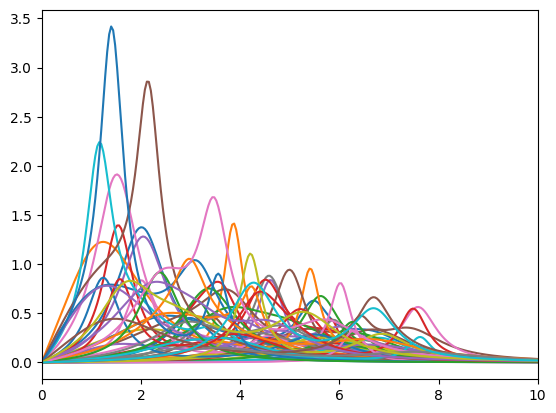

In [4]:
BWparams=generateBWParameters(60,seed=1)
BWFuns = []
BWFunsOverOmega = []

for p in BWparams:
    # print(p)
    mi = p[2]
    gammai = p[1]
    ai = p[0]
    peak_number = len(mi)
    BWFuns.append(physicsHelper.BWfun(ai,gammai,mi,omega))
    BWFunsOverOmega.append(physicsHelper.BWfunOverOmega(ai,gammai,mi,omega))
    plt.plot(omega,physicsHelper.BWfun(ai,gammai,mi,omega))
plt.xlim(0,10)

In [5]:
epsilon = 0 #This epsilon controls momentum close to 0 so that kernel doesnt have zero eigenvalues
x = np.linspace(epsilon,19.2+epsilon,25)
del_xi = x[1]-x[0]

# kl_ker_Pos=correlator.KL_kernel_Position_Vacuum(x,omega)
# klW_ker_Pos=correlator.KL_kernel_Omega(correlator.KL_kernel_Position_Vacuum,x,omega)


In [6]:
from multiprocessing import Pool

#the smothness and rigde regularisation coeffcicients - feel free to modify
lambda_s_warmup = 1.0e-5
lambda_l2_warmup = 1.0e-5
lambda_s = 3.55323189e-05#1.0e-5#1.0e-4
lambda_l2 = 1e-8#6.66754659e-08#1.0e-8
epochs=3000
new_epochs = 50000


base_ep_noise=0
num_samples = 30
ep_noise=3e-2
noisy_dxi_tensor = []

correlatorseed=0

rho_list=[]
total_loss_history_list=[]
loss_history_list=[]

def func(bwfunParams):

    import models
    import lossCalculator
    import correlator
    import tensorflow as tf


    A,gamma,M = bwfunParams
    bwfun=physicsHelper.BWfun(A,gamma,M,omega)
    bwfunOverOmega=physicsHelper.BWfunOverOmega(A,gamma,M,omega)
    kl_ker_Pos=correlator.KL_kernel_Position_Vacuum(x,omega)
    klW_ker_Pos=correlator.KL_kernel_Omega(correlator.KL_kernel_Position_Vacuum,x,omega)

    Dxi = correlator.Di(kl_ker_Pos,bwfun,del_omega)

    # noisy_Dxi,custom_std=correlator.generateNoisyCorrelator(Dxi,x,base_ep_noise,seed=correlatorseed)
    # if num_samples == 1:
    #     noisy_dxi_tensor.append(noisy_Dxi)
    # else:
    #     for ii in range(num_samples):
    #         noisy_Dxi_sample,custom_std=correlator.generateNoisyCorrelator(noisy_Dxi,x,ep_noise)
    #         noisy_dxi_tensor.append(noisy_Dxi_sample)

    Dxi = correlator.Di(kl_ker_Pos,bwfun,del_omega)
    noisy_dxi_tensor, base_noisy_Dxi, custom_std = correlator.generateNoisyCorrelatorEnsemble(Dxi,x,ep_noise,num_samples,mean_noise=base_ep_noise, seed=1)


    # num_samples = 30
    gauss_width = np.ones(len(x)) #for mean square error
    gauss_width=custom_std
    constant_input = tf.constant([[1.0]], dtype=tf.float32) #NN
    kern=klW_ker_Pos


    model = models.SpectralNN(num_output_nodes=500, width=128, depth=3)
    target_output = tf.constant(base_noisy_Dxi, dtype=tf.float32)
    target_output=noisy_dxi_tensor
    lossCalc=lossCalculator.LossCalculator(model=model,
                                        y_true=target_output,
                                        kernel=kern,
                                        delomega=del_omega,
                                        x=constant_input,
                                        std=gauss_width,
                                        lambda_s_func_warmup=lambda x:lambda_s_warmup,
                                        lambda_s_func=lambda x:lambda_s,
                                        lambda_l2_func_warmup=lambda x:lambda_l2_warmup,
                                        lambda_l2_func=lambda x:lambda_l2
                                            )
    # Compile the model - one can also play with learning rate initially it is kept large to scan through a broader manifold of minima and later decreased
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3)
    trainer=models.networkTrainer(model,optimizer,lossCalc)
    total_loss_history_warmup,loss_history_warmup=trainer.train(epochs,warmup=True,verbose=True)

    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4) #notice the lower learning rate
    trainer.optimizer=optimizer
    total_loss_history,loss_history=trainer.train(new_epochs,warmup=False,verbose=True)

    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5) #notice the lower learning rate
    trainer.optimizer=optimizer
    total_loss_history_2,loss_history_2=trainer.train(2000,warmup=False,verbose=True)

    total_loss_history.extend(total_loss_history_2)
    loss_history.extend(loss_history_2)

    rho=model(constant_input)
    # rho_list.append(rho)
    # total_loss_history_list.append(total_loss_history)
    # loss_history_list.append(loss_history)
    return rho,total_loss_history,loss_history,Dxi,base_noisy_Dxi




pool=Pool(15)
rho_list,total_loss_history_list,loss_history_list,Dxi,noisy_Dxi=zip(*pool.map(func,BWparams))

# results.wait()

pool.close()
rho_list=np.array(rho_list)
total_loss_history_list=np.array(total_loss_history_list)
loss_history_list=np.array(loss_history_list)
Dxi=np.array(Dxi)
noisy_Dxi=np.array(noisy_Dxi)




2025-01-16 09:02:54.104356: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-01-16 09:02:54.104356: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-01-16 09:02:54.104363: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-01-16 09:02:54.104354: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly 

Training for 3000 epochsTraining for 3000 epochs
Training for 3000 epochs

Training for 3000 epochs
Training for 3000 epochsTraining for 3000 epochs

Training for 3000 epochs
Training for 3000 epochs
Training for 3000 epochsTraining for 3000 epochsTraining for 3000 epochs


Training for 3000 epochs
Training for 3000 epochsTraining for 3000 epochs
Training for 3000 epochs



2025-01-16 09:02:56.162925: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2025-01-16 09:02:56.162925: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2025-01-16 09:02:56.162925: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2025-01-16 09:02:56.162925: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2025-01-16 09:02:56.162926: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2025-01-16 09:02:56.162925: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:1

Epoch 0, Loss: 756.4110717773438
Epoch 0, Loss: 749.1309814453125
Epoch 0, Loss: 741.5652465820312
Epoch 0, Loss: 760.4238891601562Epoch 0, Loss: 754.0094604492188

Epoch 0, Loss: 738.183837890625Epoch 0, Loss: 759.810791015625

Epoch 0, Loss: 734.7382202148438
Epoch 0, Loss: 750.923583984375Epoch 0, Loss: 738.8443603515625

Epoch 0, Loss: 747.171630859375
Epoch 0, Loss: 755.7489624023438
Epoch 0, Loss: 754.859130859375Epoch 0, Loss: 751.1055908203125

Epoch 0, Loss: 745.3133544921875
Epoch 300, Loss: 0.014484758488833904
Epoch 300, Loss: 0.010259918868541718
Epoch 300, Loss: 0.001050618477165699
Epoch 300, Loss: 0.0127163240686059
Epoch 300, Loss: 0.004863668233156204
Epoch 300, Loss: 0.0008158991695381701
Epoch 300, Loss: 0.028664197772741318
Epoch 300, Loss: 0.008205965161323547
Epoch 300, Loss: 0.005575123243033886
Epoch 300, Loss: 0.014486053958535194
Epoch 300, Loss: 0.02956077829003334
Epoch 300, Loss: 0.0017448379658162594
Epoch 300, Loss: 0.016138853505253792
Epoch 300, Loss: 

2025-01-16 09:20:28.394307: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-01-16 09:20:28.395073: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-01-16 09:20:28.397818: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-01-16 09:20:28.407311: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1737015628.430449   28194 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1737015628.43

Epoch 1600, Loss: 1.864942896645516e-05
Epoch 1800, Loss: 3.481032035779208e-05
Epoch 1600, Loss: 1.2636321116588078e-05
Epoch 1400, Loss: 3.8129652239149436e-05
Epoch 1000, Loss: 9.85615624813363e-05
Epoch 1800, Loss: 4.0106653614202514e-05
Epoch 1200, Loss: 1.4066274161450565e-05


2025-01-16 09:20:30.653178: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1200, Loss: 9.804993169382215e-05
Epoch 1800, Loss: 4.224073200020939e-05
Epoch 1200, Loss: 1.1819658539025113e-05
Epoch 1400, Loss: 9.155931184068322e-05
Epoch 1600, Loss: 2.9947445000289008e-05
Epoch 1600, Loss: 3.259574077674188e-05
Epoch 1400, Loss: 3.0505216273013502e-05
Training took 39.54931592941284 seconds
Epoch 1800, Loss: 1.86488323379308e-05
Epoch 1600, Loss: 3.8128990127006546e-05
Epoch 300, Loss: 0.004757340531796217
Epoch 1800, Loss: 1.2635701750696171e-05
Epoch 1200, Loss: 9.856113319983706e-05
Training took 40.08576488494873 seconds
Epoch 1400, Loss: 1.406581031915266e-05
Epoch 1400, Loss: 9.8044314654544e-05
Training took 38.768433570861816 seconds
Training for 3000 epochs
Epoch 0, Loss: 734.7896728515625
Epoch 1600, Loss: 9.155875886790454e-05
Epoch 1400, Loss: 1.1819049177574925e-05
Epoch 1800, Loss: 2.9946972063044086e-05
Epoch 1800, Loss: 3.2595231459708884e-05
Epoch 1600, Loss: 3.0504585083690472e-05
Training took 39.00246024131775 seconds
Epoch 1800, Loss:

In [7]:
# np.save('data/rho_Multifit_30_corrs_NN',rho)
# np.save('data/total_loss_history_Multifit_30_corrs_NN',total_loss_history)
# np.save('data/loss_history_Multifit_30_corrs_NN',loss_history)

# np.save('data/rho_Multifit_30_corrs_rhoFit_NN',rho)
# np.save('data/total_loss_history_Multifit_30_corrs_rhoFit_NN',total_loss_history)
# np.save('data/loss_history_Multifit_30_corrs_rhoFit_NN',loss_history)

In [12]:
def bootstrapMean(samples):
    mean=np.mean(samples,axis=0)
    mean=np.squeeze(mean)
    return mean

def bootstrapVariance(samples):
    mean=bootstrapMean(samples)
    variance=np.mean((samples-mean)**2,axis=0)
    return variance

In [12]:
BWFuns[0].shape

(500,)

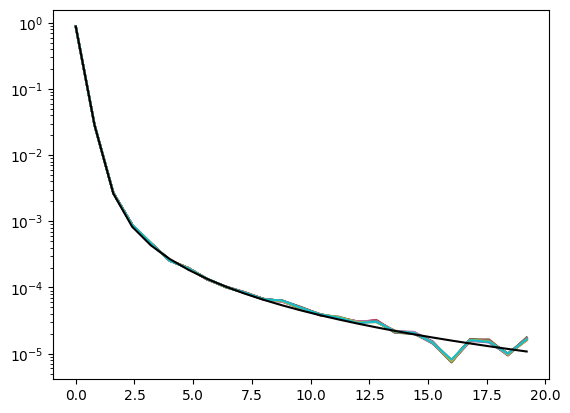

In [21]:
import models
import lossCalculator
import correlator
import tensorflow as tf

bwfun=BWFuns[4]
kl_ker_Pos=correlator.KL_kernel_Position_Vacuum(x,omega)
klW_ker_Pos=correlator.KL_kernel_Omega(correlator.KL_kernel_Position_Vacuum,x,omega)
Dxi = correlator.Di(kl_ker_Pos,bwfun,del_omega)

noisy_Dxi,custom_std=correlator.generateNoisyCorrelator(Dxi,x,base_ep_noise,seed=correlatorseed)
if num_samples == 1:
    noisy_dxi_tensor.append(noisy_Dxi)
else:
    for ii in range(num_samples):
        noisy_Dxi_sample,custom_std=correlator.generateNoisyCorrelator(noisy_Dxi,x,ep_noise)
        noisy_dxi_tensor.append(noisy_Dxi_sample)
        plt.plot(x,noisy_Dxi_sample)
    

plt.plot(x,Dxi,label='True',color='black')

plt.yscale('log')


Text(0, 0.5, '$\\rho$')

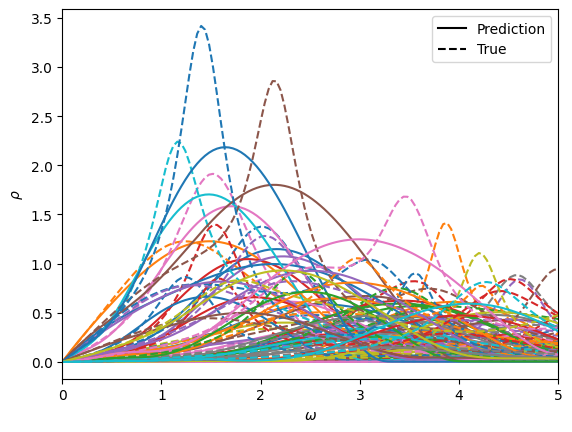

In [7]:
from matplotlib.lines import Line2D
len=100
i=0
for rho,bwfun in zip(rho_list,BWFuns):
    if i == len:
        break
    i+=1
    lines=plt.plot(omega,rho[0,:]*omega)
    c=lines[0].get_color()
    plt.plot(omega,bwfun,color=c,linestyle='--')

handles=[]
line = Line2D([0], [0], label='Prediction', color='k')
lineTrue=Line2D([0], [0], label='True', color='k',linestyle='--')
handles.append(line)
handles.append(lineTrue)

plt.legend(handles=handles)
plt.xlim(0,5)
plt.xlabel(r'$\omega$')
plt.ylabel(r'$\rho$')


Text(0, 0.5, '$\\rho$')

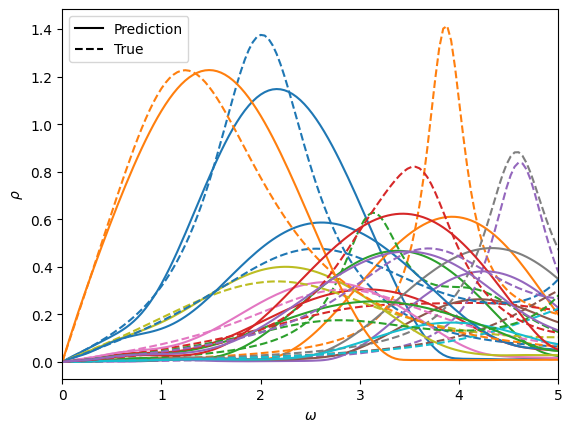

In [11]:
from matplotlib.lines import Line2D
len=15
i=0
for rho,bwfun in zip(rho_list,BWFuns):
    if i == len:
        break
    i+=1
    lines=plt.plot(omega,rho[0,:]*omega)
    c=lines[0].get_color()
    plt.plot(omega,bwfun,color=c,linestyle='--')

handles=[]
line = Line2D([0], [0], label='Prediction', color='k')
lineTrue=Line2D([0], [0], label='True', color='k',linestyle='--')
handles.append(line)
handles.append(lineTrue)

plt.legend(handles=handles)
plt.xlim(0,5)
plt.xlabel(r'$\omega$')
plt.ylabel(r'$\rho$')


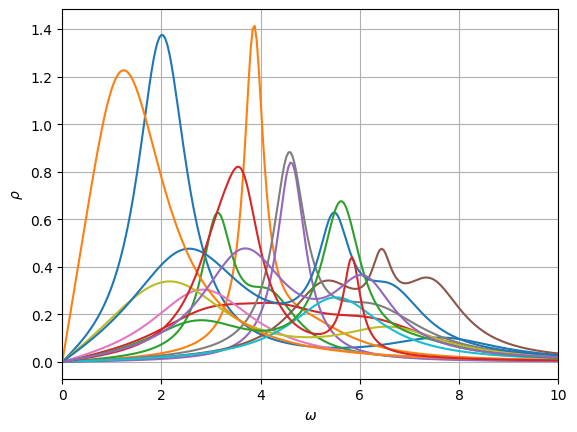

In [23]:
from matplotlib.lines import Line2D
len=15
i=0
for rho,bwfun in zip(rho_list,BWFuns):
    if i == len:
        break
    i+=1
    # # lines=plt.plot(omega,rho[0,:]*omega)
    # c=lines[0].get_color()
    plt.plot(omega,bwfun)

# handles=[]
# line = Line2D([0], [0], label='Prediction', color='k')
# lineTrue=Line2D([0], [0], label='True', color='k',linestyle='--')
# handles.append(line)
# handles.append(lineTrue)

# plt.legend(handles=handles)
plt.xlim(0,10)
plt.xlabel(r'$\omega$')
plt.ylabel(r'$\rho$')
plt.grid()

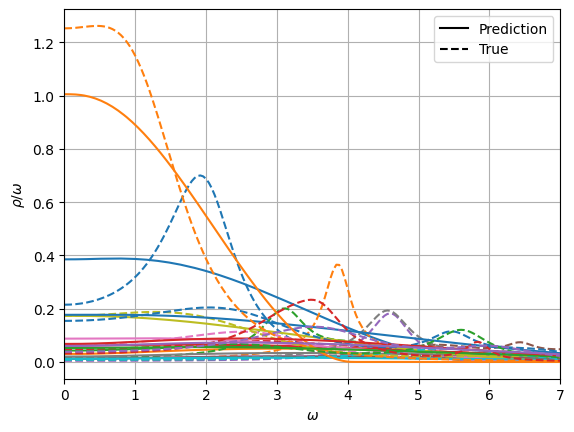

In [8]:
from matplotlib.lines import Line2D
len=15
i=0
for rho,bwfun in zip(rho_list,BWFunsOverOmega):
    if i == len:
        break
    i+=1
    lines=plt.plot(omega,rho[0,:])
    c=lines[0].get_color()
    plt.plot(omega,bwfun,color=c,linestyle='--')

handles=[]
line = Line2D([0], [0], label='Prediction', color='k')
lineTrue=Line2D([0], [0], label='True', color='k',linestyle='--')
handles.append(line)
handles.append(lineTrue)

plt.legend(handles=handles)
plt.xlim(0,7)
plt.xlabel(r'$\omega$')
plt.ylabel(r'$\rho/\omega$')
plt.grid()


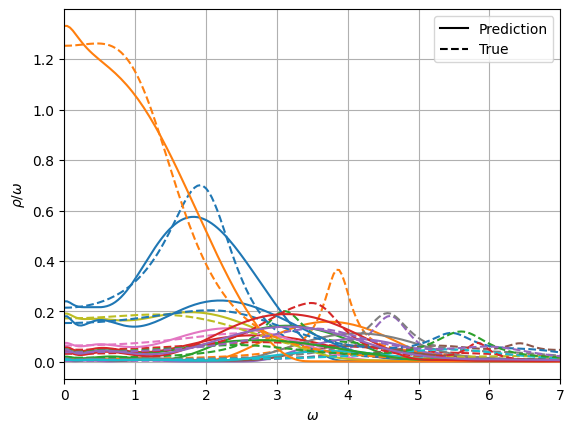

In [12]:
from matplotlib.lines import Line2D
len=15
i=0
for rho,bwfun in zip(rho_list,BWFunsOverOmega):
    if i == len:
        break
    i+=1
    lines=plt.plot(omega,rho[0,:])
    c=lines[0].get_color()
    plt.plot(omega,bwfun,color=c,linestyle='--')

handles=[]
line = Line2D([0], [0], label='Prediction', color='k')
lineTrue=Line2D([0], [0], label='True', color='k',linestyle='--')
handles.append(line)
handles.append(lineTrue)

plt.legend(handles=handles)
plt.xlim(0,7)
plt.xlabel(r'$\omega$')
plt.ylabel(r'$\rho/\omega$')
plt.grid()


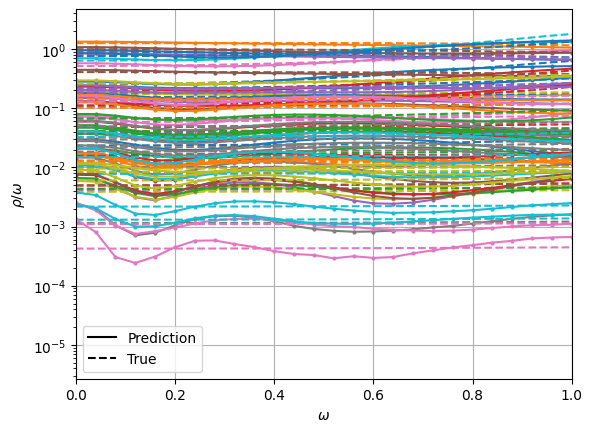

In [9]:
from matplotlib.lines import Line2D
for rho,bwfun in zip(rho_list,BWFunsOverOmega):
    lines=plt.plot(omega,rho[0,:],marker='o',ms=2)
    c=lines[0].get_color()
    plt.plot(omega,bwfun,color=c,linestyle='--')

handles=[]
line = Line2D([0], [0], label='Prediction', color='k')
lineTrue=Line2D([0], [0], label='True', color='k',linestyle='--')
handles.append(line)
handles.append(lineTrue)

plt.legend(handles=handles)
plt.xlim(0,1)
# plt.ylim(1e-3,1.5)
plt.xlabel(r'$\omega$')
plt.ylabel(r'$\rho/\omega$')
plt.yscale('log')
plt.grid()


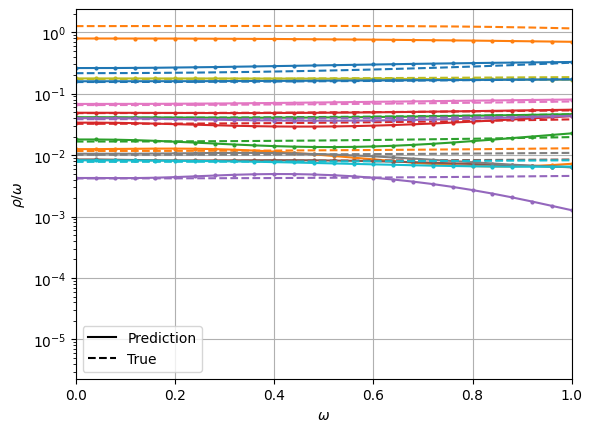

In [10]:
from matplotlib.lines import Line2D
for rho,bwfun in zip(rho_list,BWFunsOverOmega):
    lines=plt.plot(omega,rho[0,:],marker='o',ms=2)
    c=lines[0].get_color()
    plt.plot(omega,bwfun,color=c,linestyle='--')

handles=[]
line = Line2D([0], [0], label='Prediction', color='k')
lineTrue=Line2D([0], [0], label='True', color='k',linestyle='--')
handles.append(line)
handles.append(lineTrue)

plt.legend(handles=handles)
plt.xlim(0,1)
# plt.ylim(1e-3,1.5)
plt.xlabel(r'$\omega$')
plt.ylabel(r'$\rho/\omega$')
plt.yscale('log')
plt.grid()


In [26]:
def rhoOmega_offset(rho_true,rho_pred,range=3):
    return np.sum(np.abs(rho_true[:range]-rho_pred[:range]))/range

In [13]:
def rhoOmega_offsetRelative(rho_true,rho_pred,range=3):
    return np.sum(np.abs(rho_true[:range]-rho_pred[:range])/rho_true[:range])/range

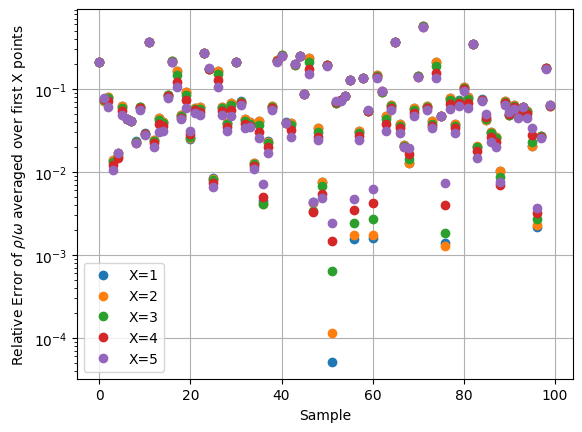

In [11]:
for j in np.arange(1,6):
    vals=[]
    for i,(rho,bwfun) in enumerate(zip(rho_list,BWFunsOverOmega)):
        val=rhoOmega_offsetRelative(bwfun,rho[0],range=j)#((bwfun[0]+bwfun[0])/2)
        vals.append(val)
    plt.plot(vals,marker='o',ls='None',label='X='+str(j))

plt.xlabel('Sample')
plt.ylabel(r'Relative Error of $\rho/\omega$ averaged over first X points')
plt.grid()
plt.legend()
plt.yscale('log')

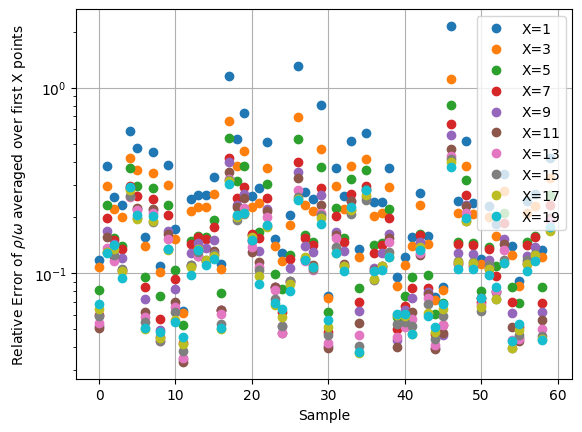

In [16]:
for j in np.arange(1,20,2):
    vals=[]
    for i,(rho,bwfun) in enumerate(zip(rho_list,BWFunsOverOmega)):
        val=rhoOmega_offsetRelative(bwfun,rho[0],range=j)#((bwfun[0]+bwfun[0])/2)
        vals.append(val)
    plt.plot(vals,marker='o',ls='None',label='X='+str(j))

plt.xlabel('Sample')
plt.ylabel(r'Relative Error of $\rho/\omega$ averaged over first X points')
plt.grid()
plt.legend()
plt.yscale('log')

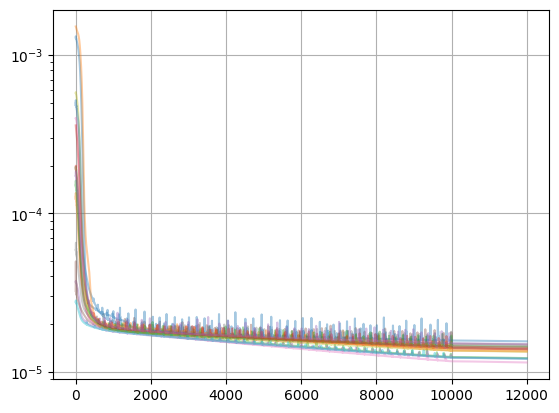

In [16]:
for train_loss in total_loss_history_list:
    plt.plot(train_loss,alpha=0.4)
plt.yscale('log')
plt.grid()

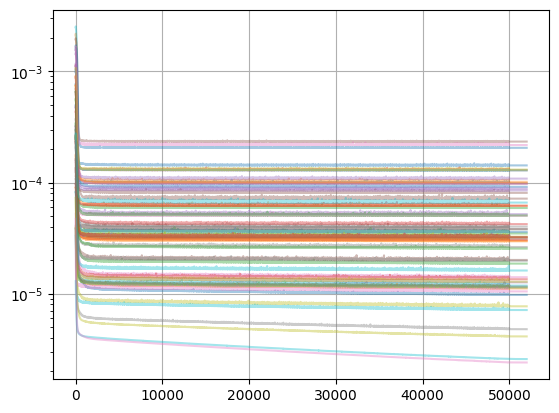

In [17]:
for train_loss in total_loss_history_list:
    plt.plot(train_loss,alpha=0.4)
plt.yscale('log')
plt.grid()

In [14]:
for rho,bwfun in zip(rho_list,BWFunsOverOmega):
    Dxi_reconstructed=correlator.Di(klW_ker_Pos,rho[0,:],del_omega)
    lines=plt.plot(x,Dxi_reconstructed,marker='o')
    c=lines[0].get_color()
    Dxi = correlator.Di(klW_ker_Pos,bwfun,del_omega)
    plt.plot(x,Dxi,linestyle='--',color=c)
plt.yscale('log')
plt.grid()
plt.xlim(None,5)

NameError: name 'correlator' is not defined

In [14]:
for rho,bwfun in zip(rho_list,BWFunsOverOmega):
    Dxi_reconstructed=correlator.Di(klW_ker_Pos,rho[0,:],del_omega)
    Dxi = correlator.Di(klW_ker_Pos,bwfun,del_omega)
    relative_diff=np.abs(Dxi_reconstructed-Dxi)/np.abs(Dxi)
    plt.plot(x,relative_diff,marker='o')
plt.yscale('log')
plt.grid()
plt.xlabel(r'$x$')
plt.ylabel('Relative Error of the correlator')

NameError: name 'correlator' is not defined

In [13]:
for rho,bwfun in zip(rho_list,BWFunsOverOmega):
    Dxi_reconstructed=correlator.Di(klW_ker_Pos,rho[0,:],del_omega)
    Dxi = correlator.Di(klW_ker_Pos,bwfun,del_omega)
    relative_diff=np.abs(Dxi_reconstructed-Dxi)/np.abs(Dxi)
    plt.plot(x,relative_diff,marker='o')
plt.yscale('log')
plt.grid()
plt.xlabel(r'$x$')
plt.ylabel('Relative Error of the correlator')

NameError: name 'correlator' is not defined